In [22]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# load the songs data

df_songs = pd.read_csv(r'D:\vs code projects\spotify_recommender_system\data\raw\Music Info.csv')
df_songs.head()

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4




Dask DataFrame is a parallel/distributed computing library that mimics the pandas API but can handle datasets larger than memory by splitting the data into many smaller pandas DataFrames (called partitions) and processing them in parallel — either across multiple CPU cores on one machine, or across a cluster of machines.

In [6]:
pip install dask[dataframe]

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 825.9 kB/s eta 0:00:02
   ---------------------------- ----------- 1.0/1.5 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.5 MB/s  0:00:01

   ---------------------------------------- 0/4 [toolz]
   ---------------------------------------- 0/4 [toolz]
   ---------------------------------------- 0/4 [toolz]
   ---------------------------------------- 0/4 [toolz]
   ---------------------------------------- 0/4 [toolz]
   -------------------- ------------------- 2/4 [partd]
   -------------------- ------------------- 2/4 [partd]
   ------------------------------ --------- 3/4 [dask]
   ------------------------------ --------- 3/4 [dask]
   ------------------------------ --------- 3/4 [dask]
   -----

In [9]:
import dask.dataframe as dd

# Load the dataset
df_users = dd.read_csv(r'D:\vs code projects\spotify_recommender_system\data\raw\User Listening History.csv')

df_users.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [10]:
df_users.npartitions

9

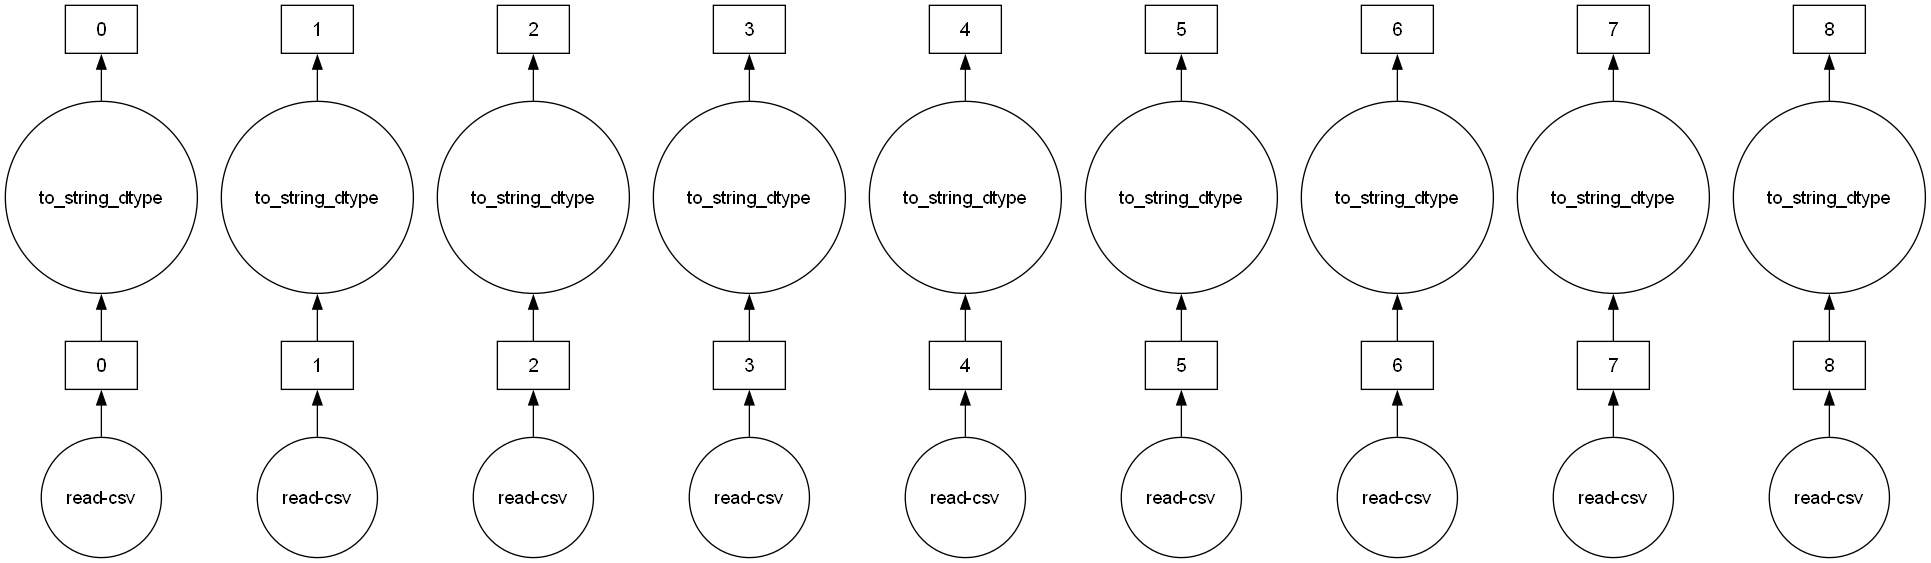

In [11]:
df_users.visualize(tasks=True)

In [12]:
# number of unique tracks in the data

unique_tracks = df_users.loc[:,"track_id"].nunique()

unique_tracks = unique_tracks.compute()

unique_tracks

np.int64(30459)

In [35]:
# number of unique users in the data

unique_users = df_users.loc[:,"user_id"].nunique()

unique_users = unique_users.compute()

unique_users

np.int64(962037)

In [13]:
# list of unique track_ids

unique_track_ids = df_users.loc[:,"track_id"].unique().compute()

unique_track_ids = unique_track_ids.tolist()

In [14]:
len(unique_track_ids)

30459

In [15]:
# filtered songs

filtered_songs = df_songs[df_songs["track_id"].isin(unique_track_ids)]

filtered_songs.reset_index(drop=True, inplace=True)

In [16]:
filtered_songs

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
3,TRXOGZT128F424AD74,Karma Police,Radiohead,https://p.scdn.co/mp3-preview/5a09f5390e2862af...,01puceOqImrzSfKDAcd1Ia,"rock, alternative, indie, alternative_rock, in...",NaN,1996,264066,0.360,...,7,-9.129,1,0.0260,0.062600,0.000092,0.1720,0.317,74.807,4
4,TRUJIIV12903CA8848,Clocks,Coldplay,https://p.scdn.co/mp3-preview/24c7fe858b234e3c...,0BCPKOYdS2jbQ8iyB56Zns,"rock, alternative, indie, pop, alternative_roc...",NaN,2002,307879,0.577,...,5,-7.215,0,0.0279,0.599000,0.011500,0.1830,0.255,130.970,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30454,TRXWSIN128F9339A11,Infinite Love Song,Maximilian Hecker,https://p.scdn.co/mp3-preview/8b3d529025fe3c60...,2eIVm8hPf59hUS2PrdoGBa,"electronic, indie_pop, love",NaN,2002,285800,0.549,...,10,-7.431,1,0.0332,0.129000,0.437000,0.1220,0.551,99.679,4
30455,TRPIGDW12903CDEB2D,Slip of the Lip,Fact,https://p.scdn.co/mp3-preview/cf64490291f9a600...,0PG7cpyNzRehf1YNIbAsol,"alternative_rock, punk_rock",Rock,2010,183640,0.423,...,2,-4.068,1,0.1840,0.000986,0.000002,0.3790,0.224,100.080,4
30456,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...,0tt1RdeJX1RyuU4hMEZ19T,NaN,NaN,2008,273440,0.438,...,6,-3.062,0,0.1650,0.003120,0.000000,0.1300,0.421,166.956,4
30457,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...,3wkdfXGf5JYErW4b35zP2h,"rock, alternative_rock, japanese, cover",NaN,2004,275133,0.351,...,0,-6.811,1,0.1200,0.000940,0.000049,0.1920,0.450,200.350,4


In [17]:
filtered_songs[filtered_songs["name"] == "Crazy in Love"]

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...,0klMKiGV38IRaBo3jjt3oC,"pop, female_vocalists, dance, soul, hip_hop, rnb",NaN,2003,249000,0.64,...,7,-5.829,1,0.218,0.00068,0.000003,0.049,0.642,99.211,4


In [26]:
import dask.dataframe as dd
import numpy as np
from scipy.sparse import csr_matrix

# Step 1: Load data with Dask
# Assume the dataset is in a CSV file

df = dd.read_csv(r'D:\vs code projects\spotify_recommender_system\data\raw\User Listening History.csv')

# Step 2: Ensure playcount is numeric
df['playcount'] = df['playcount'].astype(np.float64)
df = df.categorize(columns=['user_id', 'track_id'])

# Step 3: Convert user_id and track_id to numeric indices
# This is necessary for creating a sparse matrix later
user_mapping = df['user_id'].cat.codes
track_mapping = df['track_id'].cat.codes

df = df.assign(
    user_idx=user_mapping,
    track_idx=track_mapping
)

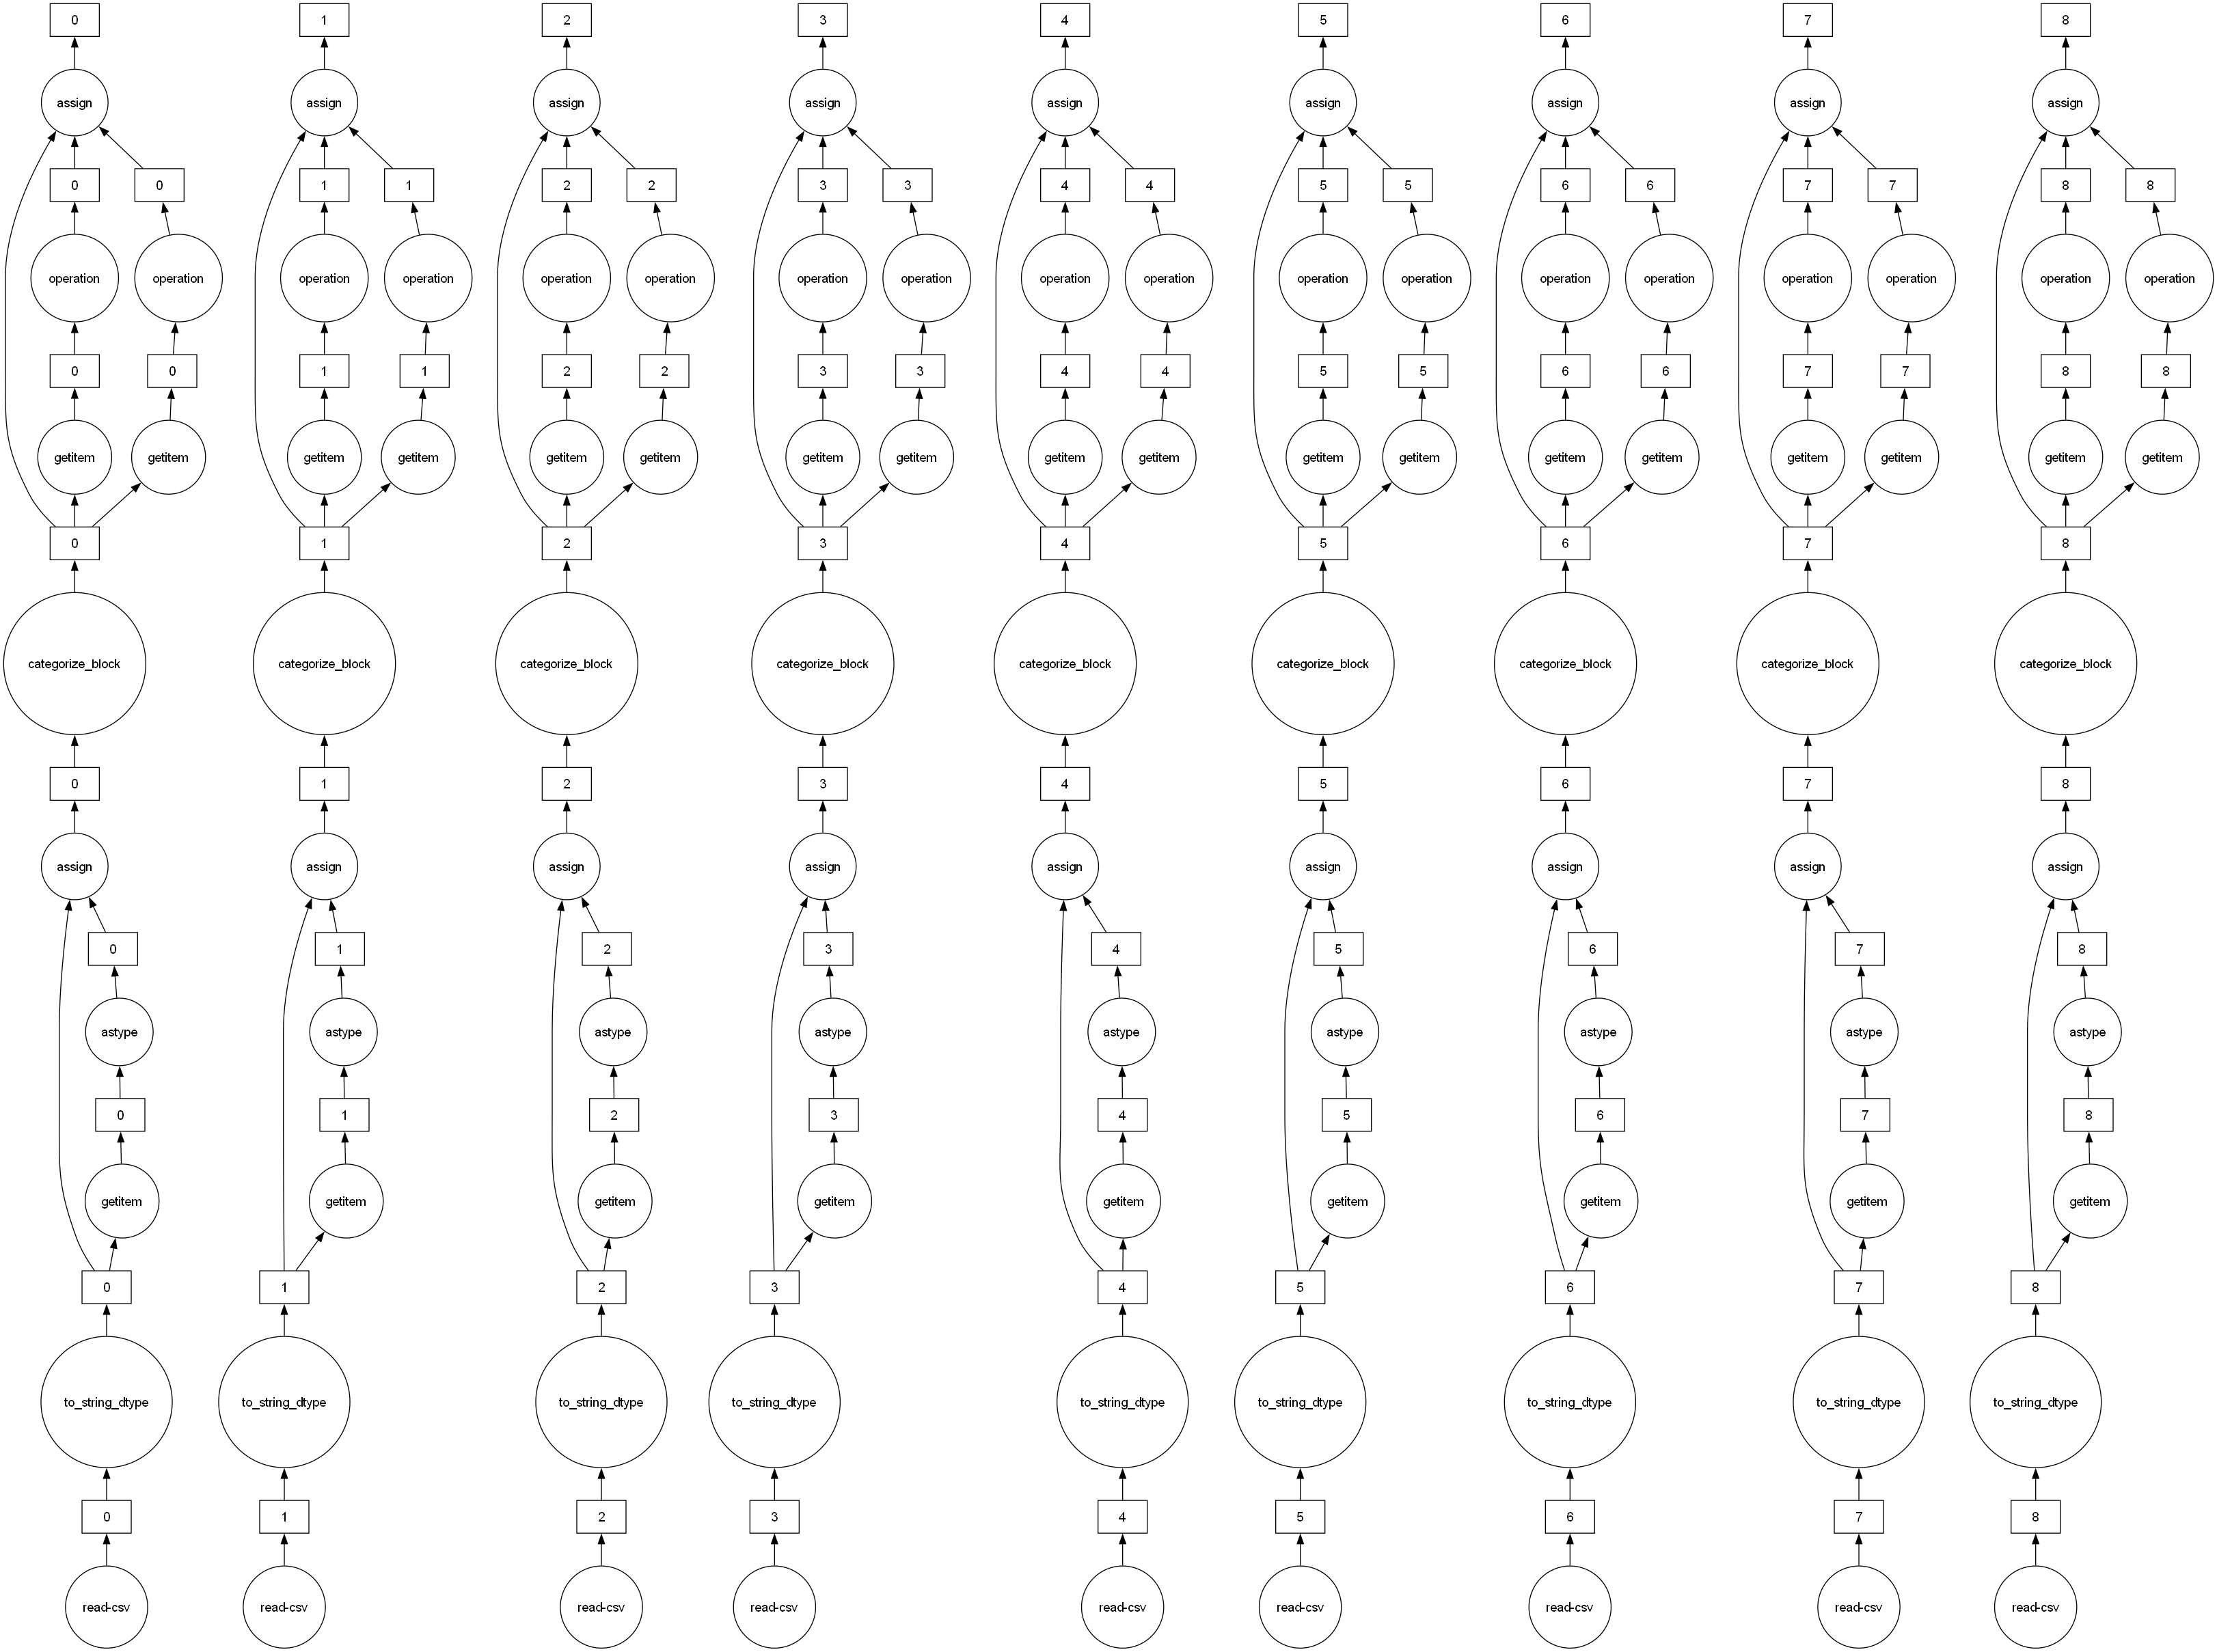

In [27]:
df.visualize(tasks=True)

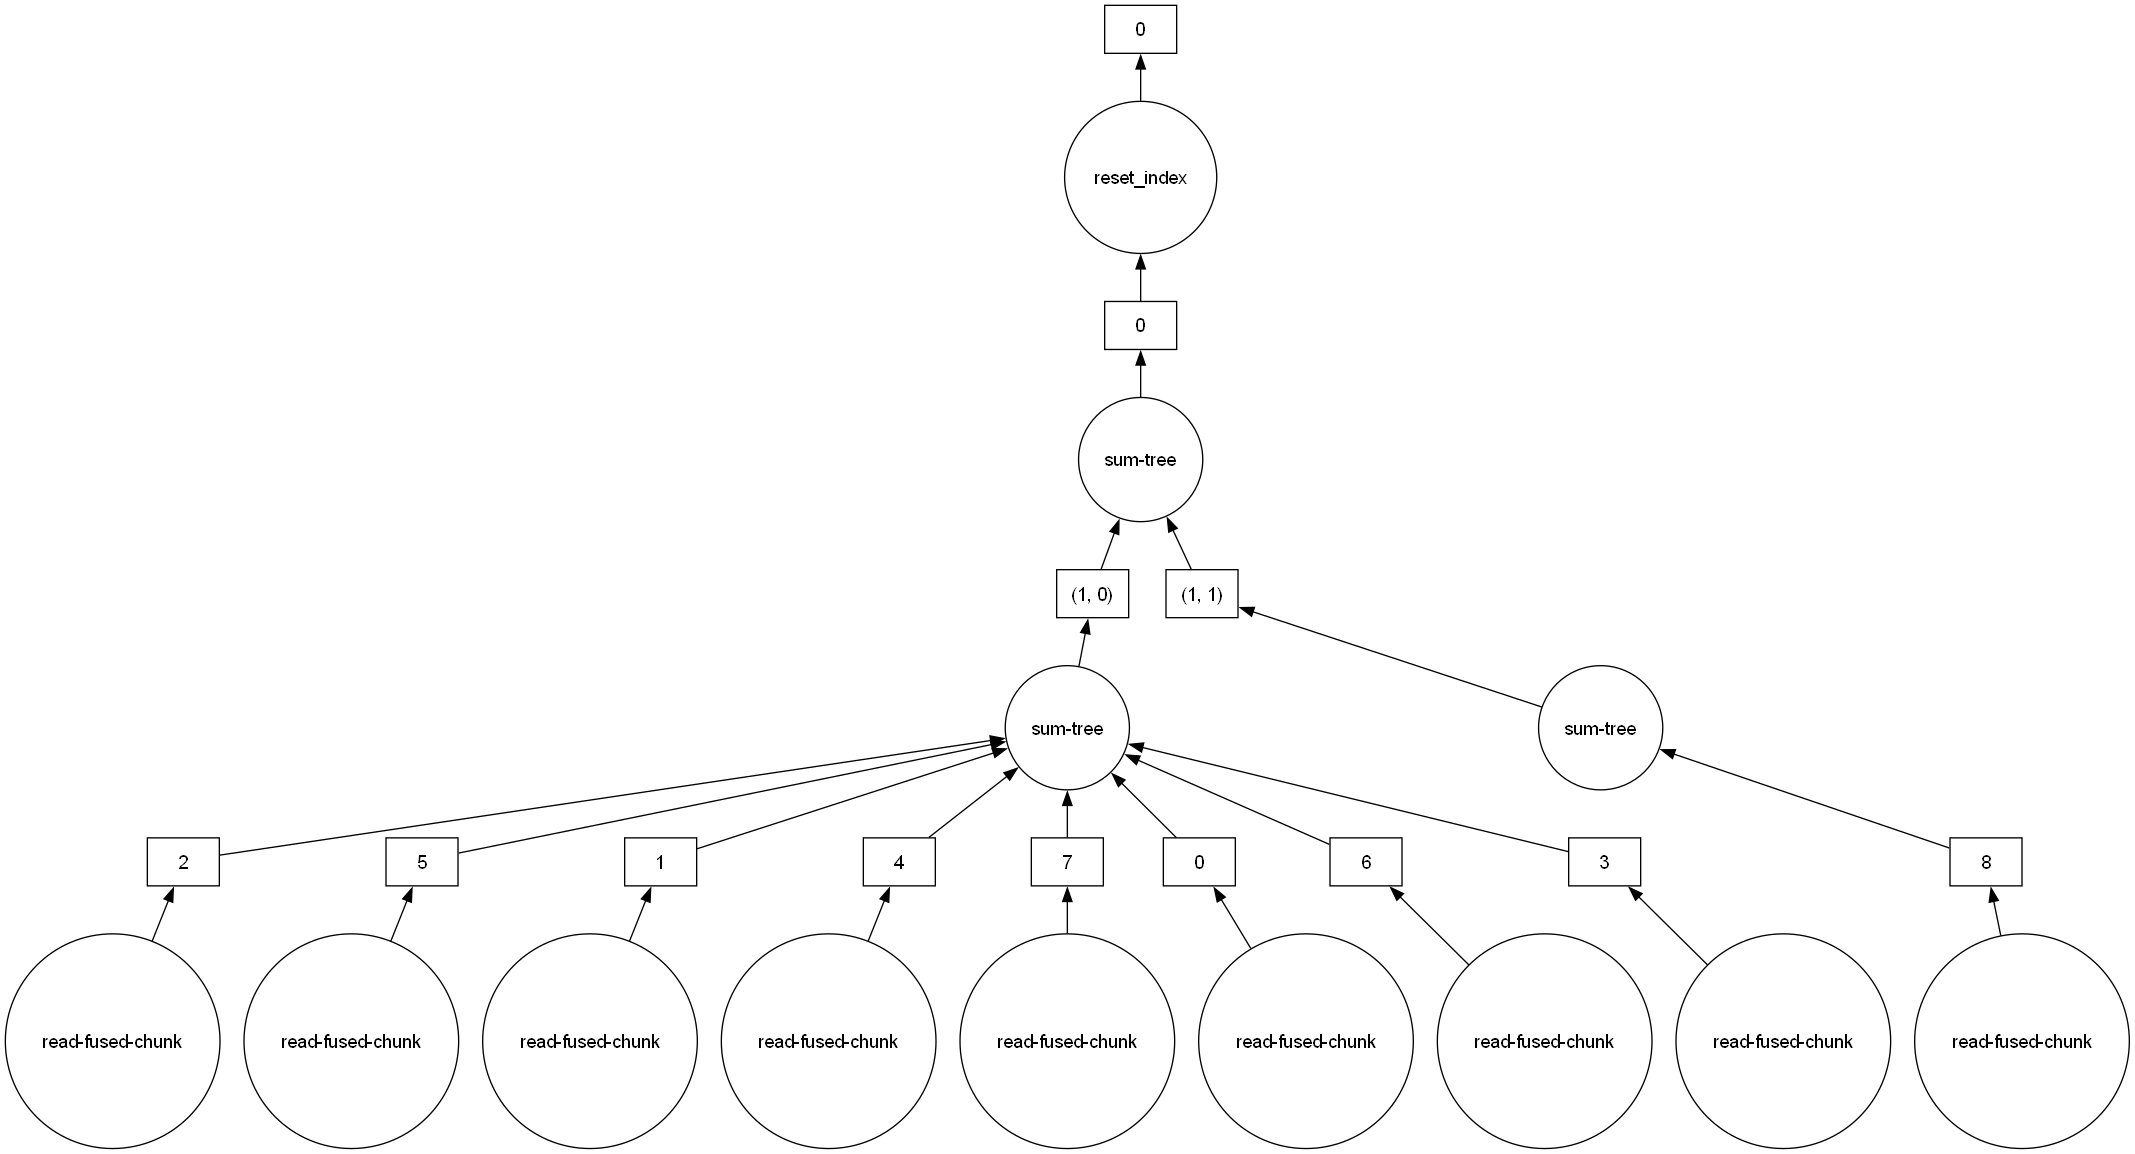

In [28]:
# Step 4: Compute the interaction matrix
# Dask doesn't support pivot tables directly, so we aggregate manually
interaction_array = df.groupby(['track_idx', 'user_idx'])['playcount'].sum().reset_index()

interaction_array.optimize().visualize(tasks=True)

In [29]:
interaction_array

,track_idx,user_idx,playcount
npartitions=1,,,
,int16,int32,float64
,...,...,...


In [30]:
interaction_array = interaction_array.compute()

In [31]:
interaction_array

,track_idx,user_idx,playcount
0,0,15780,3.0
1,0,76968,1.0
2,0,134525,2.0
3,0,231541,1.0
4,0,305348,1.0
...,...,...,...
9711296,30458,902360,1.0
9711297,30458,913310,1.0
9711298,30458,922319,1.0
9711299,30458,925779,1.0


In [32]:
# Step 5: Create a sparse matrix
# Collect the data into a NumPy-friendly format

row_indices = interaction_array['track_idx']
col_indices = interaction_array['user_idx']
values = interaction_array['playcount']


In [33]:
row_indices.nunique()

30459

In [58]:
col_indices.nunique()

962037

In [36]:
# Build a sparse matrix
n_tracks = unique_tracks
n_users = unique_users

sparse_matrix = csr_matrix((values, (row_indices, col_indices)), shape=(n_tracks, n_users))

print("Sparse matrix shape:", sparse_matrix.shape)
print("Non-zero elements:", sparse_matrix.nnz)

Sparse matrix shape: (30459, 962037)
Non-zero elements: 9711301


In [37]:
sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9711301 stored elements and shape (30459, 962037)>

In [38]:
(sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]))*100

0.033141335019756815

In [39]:
sparse_matrix[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 161 stored elements and shape (1, 962037)>

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

In [41]:
np.where(df['track_id'].cat.categories == "TROINZB128F932F740")

(array([17018]),)

In [42]:
ind = 17018

In [43]:
input_array = sparse_matrix[ind]

input_array

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 610 stored elements and shape (1, 962037)>

In [44]:
similarity_scores = cosine_similarity(input_array, sparse_matrix)

In [45]:
np.sort(similarity_scores)[-6:][::-1]

array([[0.        , 0.        , 0.        , ..., 0.07217127, 0.08225488,
        1.        ]], shape=(1, 30459))

In [46]:
similarity_scores.shape

(1, 30459)

In [47]:
np.argsort(similarity_scores.ravel())[-6:][::-1]

array([17018, 24529, 28964,  3620,  9470,  7882])

In [48]:
recommendations = df['track_id'].cat.categories[np.argsort(similarity_scores.ravel())[-6:][::-1]]

In [49]:
recommendations

Index(['TROINZB128F932F740', 'TRURCEI12903CA4395', 'TRYLWIW12903CA438D',
       'TRCVMAF12903D00E61', 'TRHRNEE12903CFDBD4', 'TRGEUXY128F4226B26'],
      dtype='string', name='track_id')

In [50]:
filtered_songs[filtered_songs["name"] == "Crazy in Love"]

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...,0klMKiGV38IRaBo3jjt3oC,"pop, female_vocalists, dance, soul, hip_hop, rnb",NaN,2003,249000,0.64,...,7,-5.829,1,0.218,0.00068,0.000003,0.049,0.642,99.211,4


In [51]:
filtered_songs[filtered_songs["track_id"].isin(recommendations)]

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...,0klMKiGV38IRaBo3jjt3oC,"pop, female_vocalists, dance, soul, hip_hop, rnb",NaN,2003,249000,0.640,...,7,-5.829,1,0.2180,0.000680,0.000003,0.049,0.6420,99.211,4
8871,TRCVMAF12903D00E61,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...,11vlxrrjPFhb1NmNgydWAX,black_metal,NaN,2006,338733,0.533,...,11,-6.973,1,0.0360,0.000044,0.447000,0.194,0.1600,125.992,4
17287,TRGEUXY128F4226B26,Monday Massacre,Mr. Oizo,https://p.scdn.co/mp3-preview/4d6dbacc93e3ef7e...,5AagWbHdT5RQz8i9JVpVS9,"electronic, house, techno, french, idm",Electronic,1999,213266,0.721,...,6,-10.269,1,0.0864,0.002320,0.886000,0.154,0.3500,158.019,4
26611,TRYLWIW12903CA438D,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...,6eim7EO1nw2pDbrREbzALA,drum_and_bass,Electronic,2005,387996,0.604,...,4,-7.941,0,0.0918,0.001440,0.832000,0.167,0.4080,173.950,4
26701,TRURCEI12903CA4395,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...,1loN5RHuhvxF2Xb4okSvHF,drum_and_bass,Electronic,2005,380081,0.410,...,7,-5.244,1,0.0495,0.000006,0.690000,0.382,0.0397,116.004,4
27774,TRHRNEE12903CFDBD4,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...,3yCWhHYCwR1vhvBseY1c8u,progressive_rock,Rock,1993,551800,0.189,...,7,-4.488,1,0.0573,0.022100,0.222000,0.153,0.2970,92.419,4


In [52]:
def collaborative_recommendation(song_name,user_data,songs_data,interaction_matrix,k=5):
    # fetch the row from songs data
    song_row = songs_data[songs_data["name"] == song_name]
    print(song_row)
    # track_id of input song
    input_track_id = song_row['track_id'].values.item()
    print(input_track_id)
    # index value of track_id
    ind = np.where(user_data['track_id'].cat.categories == input_track_id)[0].item()
    print(ind)
    # fetch the input vector
    input_array = interaction_matrix[ind]
    # get similarity scores
    similarity_scores = cosine_similarity(input_array, interaction_matrix)
    # get top k recommendations
    recommendation_track_ids = df['track_id'].cat.categories[np.argsort(similarity_scores.ravel())[-k-1:][::-1]]
    print(recommendation_track_ids)
    # get top scores
    top_scores = np.sort(similarity_scores.ravel())[-k-1:][::-1]
    print(top_scores)
    # get the songs from data and print
    temp_df = pd.DataFrame({"track_id":recommendation_track_ids.tolist(),
                            "score":top_scores})
    print(temp_df)
    top_k_songs = (
                    songs_data
                    .loc[songs_data["track_id"].isin(recommendation_track_ids)]
                    .merge(temp_df,on="track_id")
                    .sort_values(by="score",ascending=False)
                    .drop(columns=["track_id","score"])
                    .reset_index(drop=True)
                    )
    return top_k_songs

In [53]:
collaborative_recommendation(song_name="Crazy in Love",
                             user_data=df,
                             songs_data=filtered_songs,
                             interaction_matrix=sparse_matrix)

                track_id           name   artist  \
3337  TROINZB128F932F740  Crazy in Love  Beyoncé   

                                    spotify_preview_url  \
3337  https://p.scdn.co/mp3-preview/807828ea7070bda7...   

                  spotify_id  \
3337  0klMKiGV38IRaBo3jjt3oC   

                                                  tags genre  year  \
3337  pop, female_vocalists, dance, soul, hip_hop, rnb   NaN  2003   

      duration_ms  danceability  ...  key  loudness  mode  speechiness  \
3337       249000          0.64  ...    7    -5.829     1        0.218   

      acousticness  instrumentalness  liveness  valence   tempo  \
3337       0.00068          0.000003     0.049    0.642  99.211   

      time_signature  
3337               4  

[1 rows x 21 columns]
TROINZB128F932F740
17018
Index(['TROINZB128F932F740', 'TRURCEI12903CA4395', 'TRYLWIW12903CA438D',
       'TRCVMAF12903D00E61', 'TRHRNEE12903CFDBD4', 'TRGEUXY128F4226B26'],
      dtype='string', name='track_id')
[1.   

,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...,0klMKiGV38IRaBo3jjt3oC,"pop, female_vocalists, dance, soul, hip_hop, rnb",NaN,2003,249000,0.640,0.767,7,-5.829,1,0.2180,0.000680,0.000003,0.049,0.6420,99.211,4
1,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...,1loN5RHuhvxF2Xb4okSvHF,drum_and_bass,Electronic,2005,380081,0.410,0.978,7,-5.244,1,0.0495,0.000006,0.690000,0.382,0.0397,116.004,4
2,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...,6eim7EO1nw2pDbrREbzALA,drum_and_bass,Electronic,2005,387996,0.604,0.940,4,-7.941,0,0.0918,0.001440,0.832000,0.167,0.4080,173.950,4
3,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...,11vlxrrjPFhb1NmNgydWAX,black_metal,NaN,2006,338733,0.533,0.953,11,-6.973,1,0.0360,0.000044,0.447000,0.194,0.1600,125.992,4
4,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...,3yCWhHYCwR1vhvBseY1c8u,progressive_rock,Rock,1993,551800,0.189,0.858,7,-4.488,1,0.0573,0.022100,0.222000,0.153,0.2970,92.419,4
5,Monday Massacre,Mr. Oizo,https://p.scdn.co/mp3-preview/4d6dbacc93e3ef7e...,5AagWbHdT5RQz8i9JVpVS9,"electronic, house, techno, french, idm",Electronic,1999,213266,0.721,0.433,6,-10.269,1,0.0864,0.002320,0.886000,0.154,0.3500,158.019,4
